# Bio-Physical Radiant Heating — Witte et al. (2024)

**Reference:** Carson R. Witte, Ajit Subramaniam, and Christopher J. Zappa (2024).  
*An Improved Bio-Physical Parameterization for Ocean Radiant Heating in Conditions of Near-Surface Stratification.*  
JGR: Oceans, 129, e2024JC021049. https://doi.org/10.1029/2024JC021049

**Code:** https://github.com/Zappa-Lab/Bio-Physical-Radiant-Heating-Parameterization

---

## What this notebook does

Exercises the **simplified five-band parameterization** (`final_param`) from Witte et al. (2024) — the version suitable for ocean models and DWL algorithms. The functions are extracted from the Zappa-Lab toolbox and run without the external data files (spectral lookup tables) needed by the full Spectral Model.

### Figures
1. **Irradiance depth profiles** — Ed(z) for a range of chlorophyll concentrations
2. **Heating rate profiles** — –dEd/dz (W m⁻³), the source term for DWL models
3. **Scheme comparison** — Witte24 vs. Paulson & Simpson (1977), Soloviev (1982)
4. **BoB application** — Ed(z) and heating rates at typical Bay of Bengal SSRD and Chl

### Parameterization summary

Five spectral bands (UV 6%, Blue 17%, Yellow 14%, Red 14%, IR 49%) with Beer-Lambert extinction in the visible and an arctangent form for IR.
Chlorophyll-dependent Kd for UV–Red via Morel et al. (2007) power-law fits.  
Fixed albedo α = 0.045 (open-ocean, Witte et al. UAV correction to Payne 1972).

```
Ed(z) = SW*(1-α) * [Auv*exp(-Kd_UV*z) + Ab*exp(-Kd_B*z) + Ay*exp(-Kd_Y*z)
                   + Ar*exp(-Kd_R*z) + Air*exp(-C1*z)*(1 - C2*arctan(C3 + C4*z))]
```

In [8]:
# -------------------------------------------------------
# Witte et al. (2024) parameterization + classic schemes
# All functions are self-contained (pure numpy).
# Extracted from Zappa-Lab/Bio-Physical-Radiant-Heating-Parameterization
# -------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os

os.makedirs('figs', exist_ok=True)

# -------------------------------------------------------------------
# Witte et al. (2024) — simplified five-band parameterization
#
# The solar spectrum is split into five wavebands, each with a fixed
# fraction of the total surface irradiance and its own attenuation
# coefficient. Four visible bands (UV, Blue, Yellow, Red) have
# chlorophyll-dependent Kd via Morel et al. (2007) power-law fits.
# The IR band uses an arctangent profile rather than a simple
# exponential because IR is absorbed so sharply in the top centimeters
# that a pure exponential becomes numerically stiff.
# -------------------------------------------------------------------
def final_param(SW, Chl, z):
    """
    Witte et al. (2024) five-band irradiance parameterization.
    Ed(z) as a function of surface SW (W/m²), chlorophyll (mg/m³), depth z (m).
    Uses fixed open-ocean albedo α = 0.045.
    """
    # Band fractions: fraction of Ed(0+) carried by each waveband.
    # Must sum to 1.0 (UV=0.06, Blue=0.17, Yellow=0.14, Red=0.14, IR=0.49).
    Auv, Ab, Ay, Ar, Air = 0.06, 0.17, 0.14, 0.14, 0.49

    # Open-ocean albedo from Witte et al. UAV-corrected Payne (1972).
    # Ed0 = SW*(1-α) is the net downwelling just below the surface.
    alpha = 0.045

    # Morel et al. (2007) Kd(λ) = Kw + chi * Chl^e
    # Kw is the pure-water contribution; chi and e describe the
    # chlorophyll dependence. Higher Chl → larger Kd → faster attenuation.
    Kw_UV, chi_UV, e_UV = 0.0218, 0.1758, 0.6541   # UV band  (~350–400 nm)
    Kw_B,  chi_B,  e_B  = 0.0119, 0.1048, 0.6330   # Blue     (~400–500 nm)
    Kw_Y,  chi_Y,  e_Y  = 0.0665, 0.0582, 0.5342   # Yellow   (~500–570 nm)
    Kw_R,  chi_R,  e_R  = 0.3608, 0.0585, 0.4723   # Red      (~570–700 nm)

    # IR arctangent parameters (C1–C4).
    # The arctangent form captures the very rapid near-surface absorption
    # of IR while remaining well-behaved at z=0 and z→∞.
    C1, C2, C3, C4 = 1.87, 0.47, 0.66, 30

    Kd_UV = Kw_UV + chi_UV * Chl**e_UV
    Kd_B  = Kw_B  + chi_B  * Chl**e_B
    Kd_Y  = Kw_Y  + chi_Y  * Chl**e_Y
    Kd_R  = Kw_R  + chi_R  * Chl**e_R

    Ed0 = SW * (1 - alpha)   # net sub-surface irradiance (W/m²)

    return (Ed0 * Auv * np.exp(-Kd_UV * z)
          + Ed0 * Ab  * np.exp(-Kd_B  * z)
          + Ed0 * Ay  * np.exp(-Kd_Y  * z)
          + Ed0 * Ar  * np.exp(-Kd_R  * z)
          + Ed0 * Air * np.exp(-C1 * z) * (1 - C2 * np.arctan(C3 + C4 * z)))


def heating_rate(SW, Chl, z, dz=0.01):
    """
    Solar heating rate [W m⁻³] = -dEd/dz, computed by central finite difference.
    This is the volumetric heat source term used in mixed-layer and DWL models.
    A large heating rate near the surface means more heat trapped in thin layers.
    """
    return -(final_param(SW, Chl, z + dz/2) - final_param(SW, Chl, z - dz/2)) / dz


# -------------------------------------------------------------------
# Classic comparison schemes — all take I0 = net sub-surface irradiance
# (albedo already removed), unlike final_param which handles albedo internally
# -------------------------------------------------------------------
def I_ps77(I0, z):
    """
    Paulson & Simpson (1977) two-band scheme, Jerlov Type I water.
    A shallow band (e-folding ~35 cm) and a deep band (e-folding ~23 m).
    No chlorophyll dependence — fixed optical properties for clear ocean water.
    """
    return I0 * (0.58 * np.exp(-2.86 * z) + 0.42 * np.exp(-0.043 * z))

def I_s82(I0, z):
    """
    Soloviev (1982) three-band scheme — used in COARE 3.5 DWL by default.
    Slightly more spectral detail than PS77 but still no chlorophyll dependence.
    The very short e-folding (~1.4 cm) band captures UV/IR near-surface absorption.
    """
    return I0 * (0.45 * np.exp(-0.078 * z)
               + 0.27 * np.exp(-2.8   * z)
               + 0.28 * np.exp(-71    * z))

def I_ps81(I0, z):
    """
    Paulson & Simpson (1981) nine-band scheme.
    The most spectrally resolved of the classic parameterizations, covering
    UV through near-IR with nine distinct e-folding depths. Still no Chl dependence.
    """
    return I0 * (0.237  * np.exp(-0.0287 * z)
               + 0.360  * np.exp(-0.440  * z)
               + 0.179  * np.exp(-31.7   * z)
               + 0.087  * np.exp(-182    * z)
               + 0.080  * np.exp(-1200   * z)
               + 0.0246 * np.exp(-7940   * z)
               + 0.025  * np.exp(-3190   * z)
               + 0.007  * np.exp(-12800  * z)
               + 0.0004 * np.exp(-69400  * z))

print('Functions loaded: final_param, heating_rate, I_ps77, I_s82, I_ps81')

Functions loaded: final_param, heating_rate, I_ps77, I_s82, I_ps81


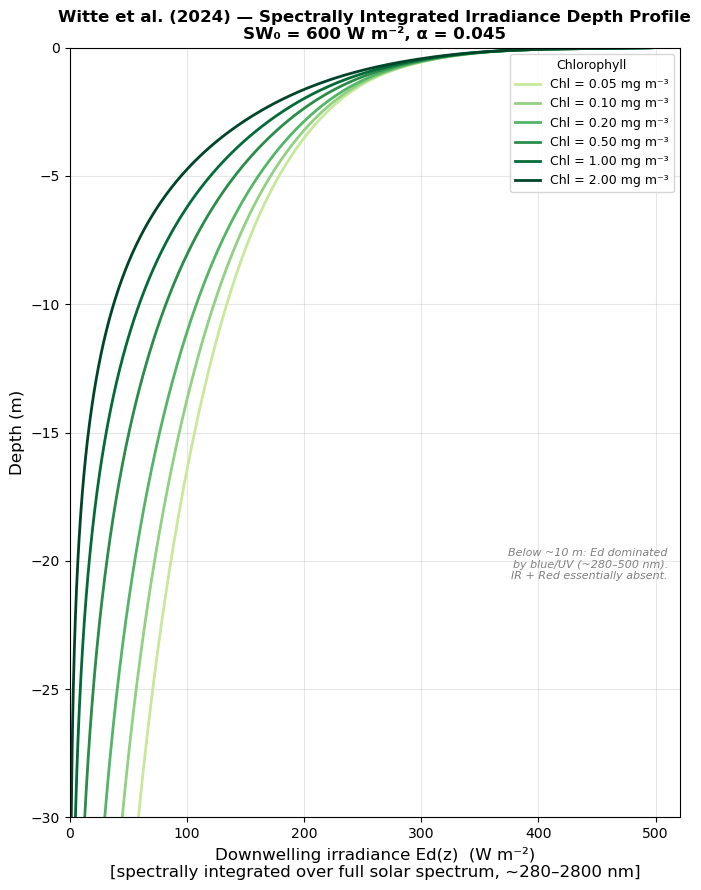

Saved figs/Witte24_depth_profiles.png


In [9]:
# -------------------------------------------------------
# Figure 1: Irradiance depth profiles at multiple Chl
# -------------------------------------------------------
# SW_ref = 600 W/m² is a representative clear-sky midday value for the
# Bay of Bengal. It sits between the pre-monsoon peak (~620 W/m²) and
# the post-monsoon mean (~550 W/m²), and keeps this figure season-agnostic.
SW_ref = 600.0   # W/m²

# Depth array from 0 to 30 m — captures the base of most DWLs (1–10 m)
# and enough below to show convergence of profiles with depth.
z_arr  = np.linspace(0, 30, 600)

# Chlorophyll range from oligotrophic open-ocean (0.05) to bloom conditions (2.00).
# The spread of curves illustrates how strongly Chl controls the attenuation
# of solar radiation in the upper thermocline.
CHL_VALS = [0.05, 0.10, 0.20, 0.50, 1.00, 2.00]   # mg/m³
CMAP     = plt.cm.YlGn(np.linspace(0.3, 1.0, len(CHL_VALS)))

fig, ax = plt.subplots(figsize=(7, 9))

for chl, color in zip(CHL_VALS, CMAP):
    Ed = final_param(SW_ref, chl, z_arr)
    ax.plot(Ed, -z_arr, color=color, lw=2,
            label=f'Chl = {chl:.2f} mg m⁻³')

ax.set_xlabel('Downwelling irradiance Ed(z)  (W m⁻²)\n[spectrally integrated over full solar spectrum, ~280–2800 nm]',
              fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_ylim(-30, 0)
ax.set_xlim(left=0)
ax.legend(fontsize=9, title='Chlorophyll', title_fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title(
    f'Witte et al. (2024) — Spectrally Integrated Irradiance Depth Profile\n'
    f'SW₀ = {SW_ref:.0f} W m⁻²',
    fontsize=12, fontweight='bold'
)

# Note: although the y-axis shows total power, the spectral character of Ed(z)
# shifts dramatically with depth. IR (~700–2800 nm, 49% of surface) is absorbed
# in the top ~0.5 m; Red (~570–700 nm, 14%) decays with ~3 m e-folding.
# Below ~10 m the integrated signal is dominated almost entirely by blue and UV
# wavelengths (~280–500 nm). The Chl-dependence seen here is therefore mainly
# a blue/UV attenuation effect at depth.
ax.text(0.98, 0.35,
        'Below ~10 m: Ed dominated\nby blue/UV (~280–500 nm).\nIR + Red essentially absent.',
        transform=ax.transAxes, fontsize=8, ha='right', va='top',
        color='gray', style='italic')

plt.tight_layout()
plt.savefig('figs/Witte24_depth_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_depth_profiles.png')

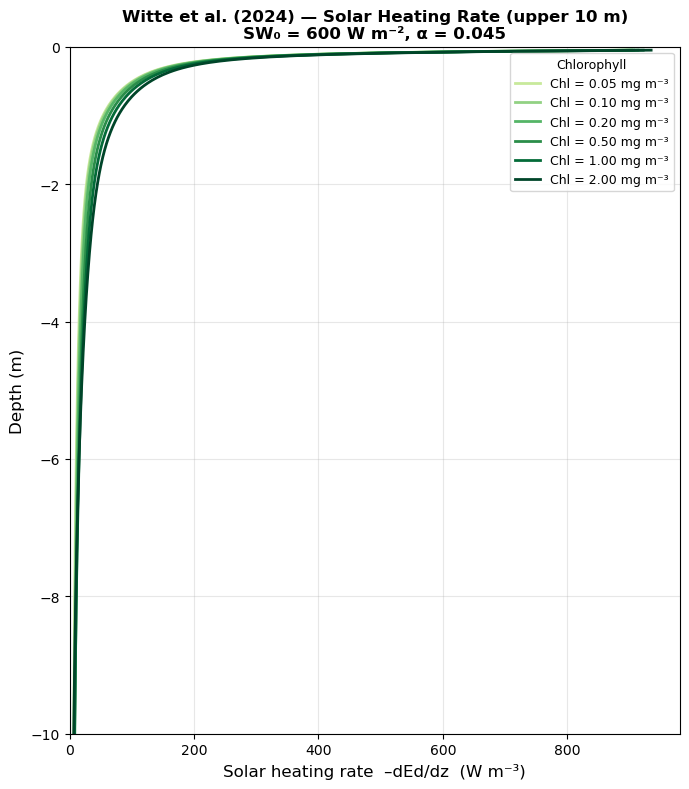

Saved figs/Witte24_heating_rate.png


In [10]:
# -------------------------------------------------------
# Figure 2: Solar heating rate = -dEd/dz (W/m³)
# -------------------------------------------------------
# The heating rate is the volumetric solar source term fed into DWL and
# mixed-layer models: dT/dt ∝ -dEd/dz / (ρ·cp).
# A large -dEd/dz near the surface means more heat is deposited in a thin
# layer, which is what drives diurnal warm layer formation under low wind.
#
# Focus on 0–10 m because that is where DWLs live. Below ~10 m the heating
# rate is small and the differences between Chl scenarios converge.
z_shallow = np.linspace(0.05, 10, 500)   # avoid z=0 where arctan term is steep

fig, ax = plt.subplots(figsize=(7, 8))

for chl, color in zip(CHL_VALS, CMAP):
    hr = heating_rate(SW_ref, chl, z_shallow)
    ax.plot(hr, -z_shallow, color=color, lw=2,
            label=f'Chl = {chl:.2f} mg m⁻³')

ax.set_xlabel('Solar heating rate  –dEd/dz  (W m⁻³)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_ylim(-10, 0)
ax.set_xlim(left=0)
ax.legend(fontsize=9, title='Chlorophyll', title_fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title(
    f'Witte et al. (2024) — Solar Heating Rate (upper 10 m)\n'
    f'SW₀ = {SW_ref:.0f} W m⁻²',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('figs/Witte24_heating_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_heating_rate.png')

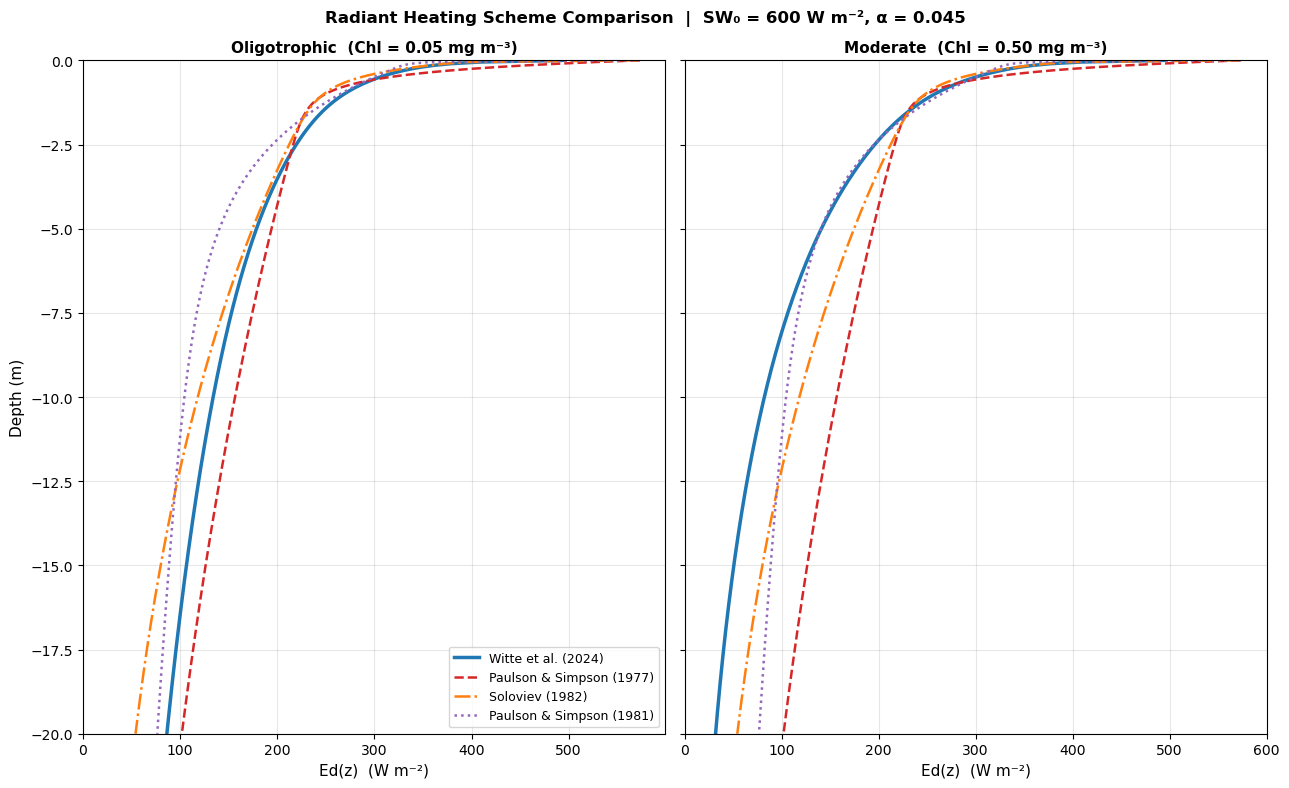

Saved figs/Witte24_scheme_comparison.png


In [11]:
# -------------------------------------------------------
# Figure 3: Scheme comparison
# Witte24 vs. Paulson & Simpson 1977, Soloviev 1982
# -------------------------------------------------------
# Two Chl scenarios bracket the range of BoB conditions:
#   Oligotrophic (0.05 mg/m³) — open-ocean, post-monsoon interior
#   Moderate     (0.50 mg/m³) — bloom onset or river-influenced water
#
# Input convention note:
#   Witte24 handles albedo internally: it takes surface SW and applies α=0.045.
#   The classic schemes (PS77, S82, PS81) expect I0 = net sub-surface irradiance
#   (i.e. albedo already removed). To compare on equal footing, pass
#   I0_net = SW*(1-α) to the classic schemes. Without this correction the
#   classic schemes would overestimate Ed by ~5% relative to Witte24.
z_arr = np.linspace(0, 20, 400)
alpha_ref = 0.045
I0_net    = SW_ref * (1 - alpha_ref)   # ~573 W/m² for SW_ref=600

fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)

for ax, chl, title_chl in zip(axes,
                               [0.05, 0.50],
                               ['Oligotrophic  (Chl = 0.05 mg m⁻³)',
                                'Moderate  (Chl = 0.50 mg m⁻³)']):
    Ed_w24  = final_param(SW_ref, chl, z_arr)   # Witte24 — Chl-dependent
    Ed_ps77 = I_ps77(I0_net, z_arr)             # PS77 — no Chl, Jerlov I
    Ed_s82  = I_s82(I0_net, z_arr)              # S82  — no Chl, COARE default
    Ed_ps81 = I_ps81(I0_net, z_arr)             # PS81 — no Chl, 9-band

    # Classic schemes are identical in both panels because they have no Chl
    # dependence — the separation shows what Chl is adding / subtracting.
    ax.plot(Ed_w24,  -z_arr, color='#1f77b4', lw=2.5, label='Witte et al. (2024)')
    ax.plot(Ed_ps77, -z_arr, color='#d62728', lw=1.8, ls='--', label='Paulson & Simpson (1977)')
    ax.plot(Ed_s82,  -z_arr, color='#ff7f0e', lw=1.8, ls='-.', label='Soloviev (1982)')
    ax.plot(Ed_ps81, -z_arr, color='#9467bd', lw=1.8, ls=':',  label='Paulson & Simpson (1981)')

    ax.set_xlabel('Ed(z)  (W m⁻²)', fontsize=11)
    ax.set_xlim(left=0)
    ax.set_ylim(-20, 0)
    ax.set_title(title_chl, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Depth (m)', fontsize=11)
        ax.legend(fontsize=9, loc='lower right')

fig.suptitle(
    f'Radiant Heating Scheme Comparison  |  SW₀ = {SW_ref:.0f} W m⁻²',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figs/Witte24_scheme_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_scheme_comparison.png')

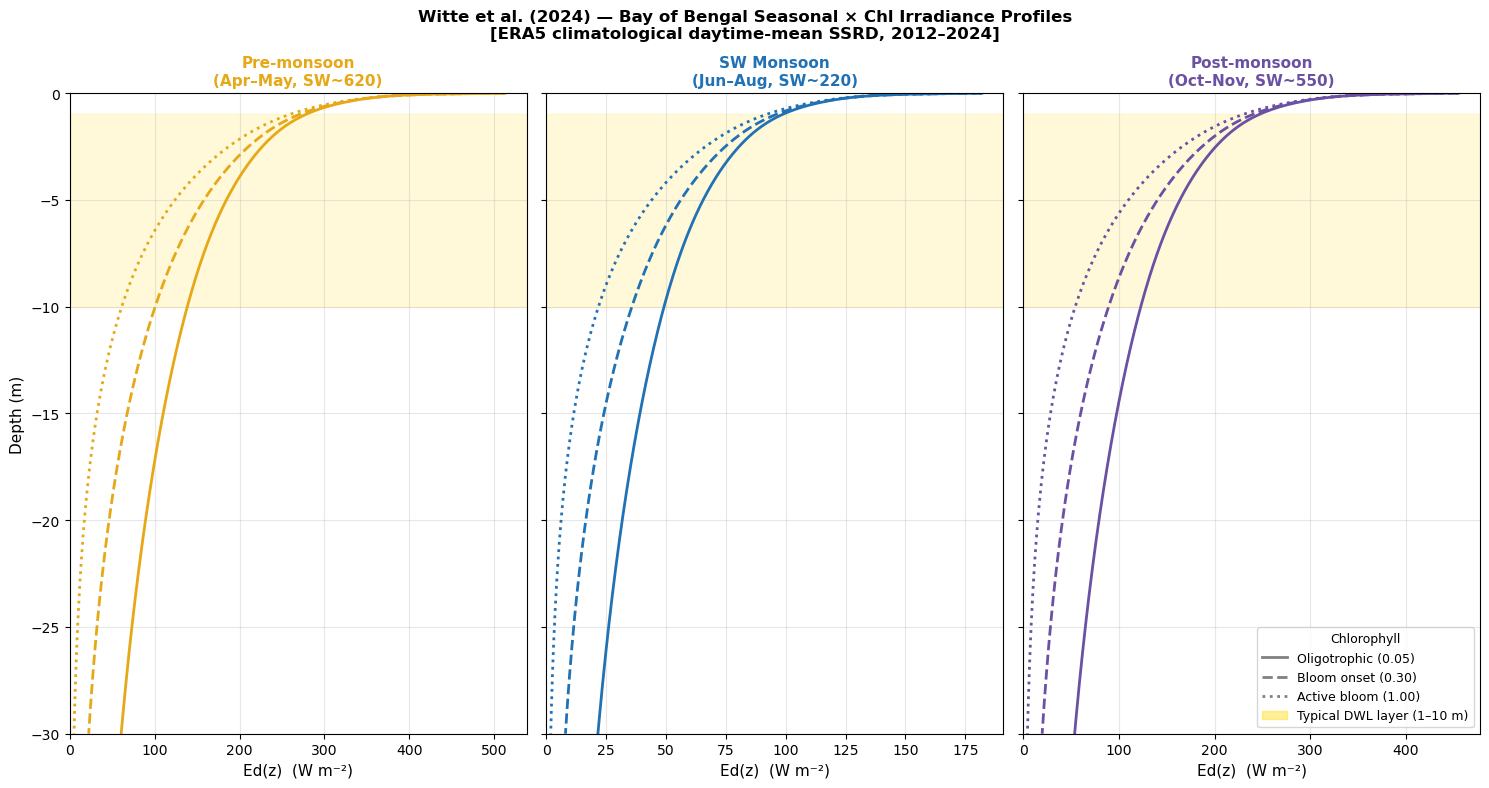

Saved figs/Witte24_BoB_application.png


In [12]:
# -------------------------------------------------------
# Figure 4: Bay of Bengal application
# -------------------------------------------------------
# Three BoB seasons defined by climatological daytime-mean SSRD from ERA5
# (2012–2024, averaged over the northern BoB, ~10–20°N):
#   Pre-monsoon (Apr–May)  ~620 W/m²  — clearest skies, peak insolation
#   SW Monsoon  (Jun–Aug)  ~220 W/m²  — heavy cloud cover suppresses SW
#   Post-monsoon (Oct–Nov) ~550 W/m²  — skies clearing after monsoon retreat
#
# Three Chl scenarios represent the biological state of the BoB:
#   0.05 mg/m³  — oligotrophic open ocean, post-monsoon interior
#   0.30 mg/m³  — bloom onset during mixed-layer shoaling
#   1.00 mg/m³  — active bloom (post-cyclone upwelling or river plume)
#
# The shaded band marks the nominal DWL depth range (1–10 m). Comparing
# how much Ed remains at 10 m across seasons and Chl shows which combinations
# produce the strongest radiant heating within the DWL.
SEASONS = {
    'Pre-monsoon\n(Apr–May, SW~620)': (620, '#e6a817'),
    'SW Monsoon\n(Jun–Aug, SW~220)':  (220, '#2171b5'),
    'Post-monsoon\n(Oct–Nov, SW~550)':(550, '#6a51a3'),
}
CHL_BOB = {'Oligotrophic (0.05)': 0.05,
            'Bloom onset (0.30)':  0.30,
            'Active bloom (1.00)': 1.00}
CHL_LS  = ['-', '--', ':']

z_arr = np.linspace(0, 30, 600)

fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True)

for ax, (season_label, (SW, col)) in zip(axes, SEASONS.items()):
    for (chl_label, chl), ls in zip(CHL_BOB.items(), CHL_LS):
        Ed = final_param(SW, chl, z_arr)
        ax.plot(Ed, -z_arr, color=col, lw=2, ls=ls, label=chl_label)

    # Highlight the DWL depth range — radiant heating in this layer drives
    # the diurnal SST signal measured by near-surface thermistors and satellites.
    ax.axhspan(-10, -1, color='gold', alpha=0.15, label='Typical DWL layer')

    ax.set_xlabel('Ed(z)  (W m⁻²)', fontsize=11)
    ax.set_xlim(left=0)
    ax.set_ylim(-30, 0)
    ax.set_title(season_label, fontsize=11, fontweight='bold', color=col)
    ax.grid(True, alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Depth (m)', fontsize=11)

# Shared legend showing line styles (Chl) and the DWL shading.
handles = [mlines.Line2D([], [], color='gray', lw=2, ls=ls, label=lbl)
           for lbl, ls in zip(CHL_BOB.keys(), CHL_LS)]
handles += [mpatches.Patch(color='gold', alpha=0.4, label='Typical DWL layer (1–10 m)')]
axes[-1].legend(handles=handles, fontsize=9, title='Chlorophyll', title_fontsize=9, loc='lower right')

fig.suptitle(
    'Witte et al. (2024) — Bay of Bengal Seasonal × Chl Irradiance Profiles\n'
    '[ERA5 climatological daytime-mean SSRD, 2012–2024]',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figs/Witte24_BoB_application.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_BoB_application.png')

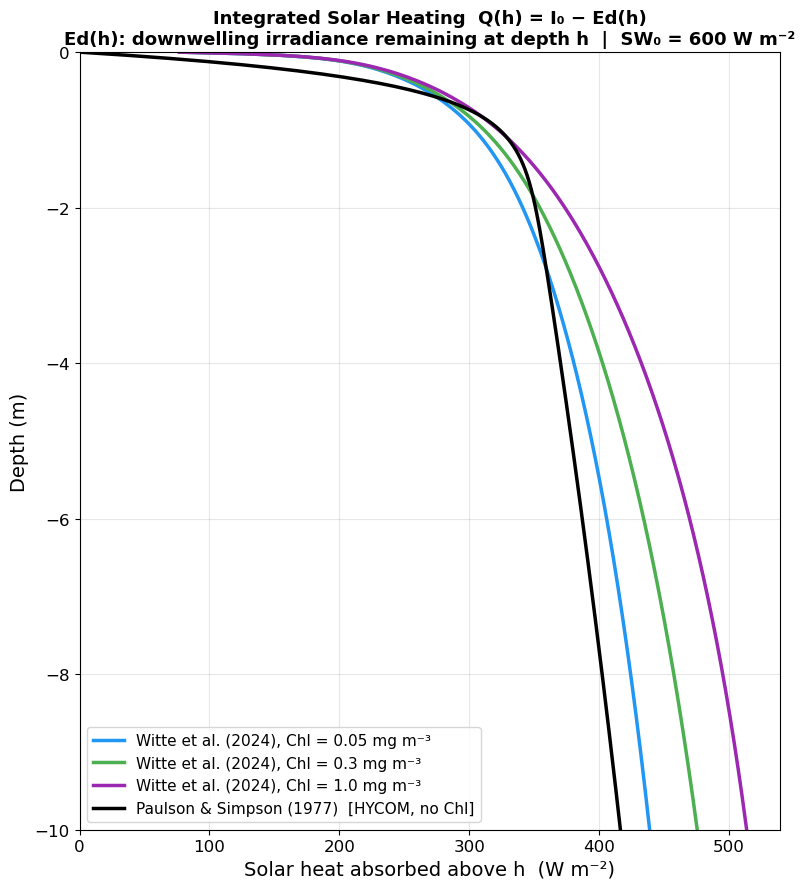

Saved figs/Witte24_integrated_heating.png


In [25]:
# -------------------------------------------------------
# Figure 5: Integrated solar heating in the upper mixed layer
# -------------------------------------------------------
# Q(h) = I0 − Ed(h): total heat absorbed between the air-sea interface and depth h,
# where I0 = SW*(1-α) is the net downwelling just below the surface.
#
# Witte24 starts at ~13% of I0 at h=0 because the arctangent IR term was fit to
# observed profiles at depth and is not constrained to Ed(0)=I0 — that fraction
# is absorbed in the optical skin above z=0. PS77 sums to 1 at z=0 so starts
# at Q=0, with its shallow exponential (e-folding 35 cm) absorbing the near-surface
# IR within the water column rather than above it.
#
# Two schemes:
#   Witte24  — five-band, Chl-dependent (colored by Chl)
#   PS77     — Paulson & Simpson (1977), two-band, no Chl; Navy operational HYCOM (black)
SW   = 600.0
alpha = 0.045
I0   = SW * (1 - alpha)

h_arr = np.linspace(0, 10, 500)

CHL_VALS = [0.05, 0.30, 1.00]
COLORS   = ['#2196F3', '#4CAF50', '#9C27B0']   # blue, green, purple

fig, ax = plt.subplots(figsize=(8, 9))

for chl, col in zip(CHL_VALS, COLORS):
    Q_w24 = I0 - final_param(SW, chl, h_arr)
    ax.plot(Q_w24, -h_arr, color=col, lw=2.5, label=f'Witte et al. (2024), Chl = {chl} mg m⁻³')

Q_ps77 = I0 - I_ps77(I0, h_arr)
ax.plot(Q_ps77, -h_arr, color='black', lw=2.5, label='Paulson & Simpson (1977)  [HYCOM, no Chl]')

ax.set_xlabel('Solar heat absorbed above h  (W m⁻²)', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_xlim(left=0)
ax.set_ylim(-10, 0)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_title(
    f'Integrated Solar Heating  Q(h) = I₀ − Ed(h)\n'
    f'Ed(h): downwelling irradiance remaining at depth h  |  SW₀ = {SW:.0f} W m⁻²',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig('figs/Witte24_integrated_heating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_integrated_heating.png')

In [ ]:
# -------------------------------------------------------
# What if Witte et al. used a PS77-style double exponential?
#
# Fit:  Ed(z)/Ed(0) = A1*exp(-K1*z) + (1-A1)*exp(-K2*z)
#       A1 + A2 = 1  enforces proper normalization at z=0
#
# Normalizing by Ed(0) = _final_param_scale(Chl, 0) fixes the
# arctangent surface BC issue — the fitted form starts at 1.0.
# K1 (fast band, IR-dominated) is roughly constant with Chl.
# K2 (slow band, visible-dominated) increases with Chl — this
# is the actual Chl signal, expressed as a single e-folding depth.
# -------------------------------------------------------
from scipy.optimize import curve_fit

# -------------------------------------------------------------------
# Helper: normalized Witte24 profile (dimensionless, z=0 → 1.0)
# -------------------------------------------------------------------
def _final_param_scale(Chl, z):
    """Witte24 irradiance fraction at depth z, given Chl. Ed(z)/I0."""
    Auv, Ab, Ay, Ar, Air = 0.06, 0.17, 0.14, 0.14, 0.49
    Kd_UV = 0.0218 + 0.1758 * Chl**0.6541
    Kd_B  = 0.0119 + 0.1048 * Chl**0.6330
    Kd_Y  = 0.0665 + 0.0582 * Chl**0.5342
    Kd_R  = 0.3608 + 0.0585 * Chl**0.4723
    C1, C2, C3, C4 = 1.87, 0.47, 0.66, 30
    return (Auv * np.exp(-Kd_UV * z)
          + Ab  * np.exp(-Kd_B  * z)
          + Ay  * np.exp(-Kd_Y  * z)
          + Ar  * np.exp(-Kd_R  * z)
          + Air * np.exp(-C1 * z) * (1 - C2 * np.arctan(C3 + C4 * z)))

def double_exp(z, A1, K1, K2):
    """Two-band exponential, PS77 form. A2 = 1 - A1 enforces z=0 normalization."""
    return A1 * np.exp(-K1 * z) + (1 - A1) * np.exp(-K2 * z)

# -------------------------------------------------------------------
# Fit to normalized Witte24 profiles across a Chl range
# -------------------------------------------------------------------
z_fit   = np.linspace(0.0, 30, 600)
CHL_FIT = np.array([0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00, 1.50, 2.00])

fitted = {}
for chl in CHL_FIT:
    Ed_raw  = np.array([_final_param_scale(chl, z) for z in z_fit])
    Ed_norm = Ed_raw / Ed_raw[0]   # normalize: Ed(z)/Ed(0), so z=0 → 1.0
    try:
        popt, _ = curve_fit(
            double_exp, z_fit, Ed_norm,
            p0=[0.58, 2.5, 0.05],
            bounds=([0.2, 0.5, 0.005], [0.9, 20.0, 3.0]),
            maxfev=10000,
        )
        fitted[chl] = dict(A1=popt[0], K1=popt[1], K2=popt[2])
    except RuntimeError as e:
        print(f'Chl={chl:.2f}: fit failed — {e}')

# --- Parameter table ---
print(f'{"Chl":>6}  {"A1":>6}  {"A2":>6}  {"K1 (m⁻¹)":>10}  {"z_e1 (m)":>9}  {"K2 (m⁻¹)":>10}  {"z_e2 (m)":>9}')
print('  PS77   0.580   0.420      2.860      0.350      0.043     23.26')
print('─' * 72)
for chl, p in fitted.items():
    print(f'{chl:6.2f}  {p["A1"]:6.3f}  {1-p["A1"]:6.3f}  {p["K1"]:10.3f}  '
          f'{1/p["K1"]:9.3f}  {p["K2"]:10.4f}  {1/p["K2"]:9.2f}')

# -------------------------------------------------------------------
# Figure: three panels
# -------------------------------------------------------------------
SEL_CHL    = [0.05, 0.30, 1.00, 2.00]
SEL_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
z_plt = np.linspace(0, 20, 400)
h_arr = np.linspace(0.01, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.suptitle(
    'What if Witte et al. (2024) used a PS77-style double exponential?\n'
    'Fit:  Ed(z)/Ed(0) = A₁ · exp(−K₁z) + A₂ · exp(−K₂z),   A₁+A₂ = 1',
    fontsize=13, fontweight='bold'
)

# --- Panel 1: Profile fit quality ---
ax = axes[0]
for chl, col in zip(SEL_CHL, SEL_COLORS):
    Ed_raw  = np.array([_final_param_scale(chl, z) for z in z_plt])
    Ed_norm = Ed_raw / Ed_raw[0]
    p = fitted[chl]
    Ed_fit  = double_exp(z_plt, p['A1'], p['K1'], p['K2'])
    ax.plot(Ed_norm, -z_plt, color=col, lw=2.5, label=f'Witte24  Chl = {chl:.2f}')
    ax.plot(Ed_fit,  -z_plt, color=col, lw=1.3, ls='--', alpha=0.85)

Ed_ps77_plt = 0.58 * np.exp(-2.86 * z_plt) + 0.42 * np.exp(-0.043 * z_plt)
ax.plot(Ed_ps77_plt, -z_plt, 'k-', lw=2.2, label='PS77 (HYCOM)')

ax.set_xlabel('Ed(z) / Ed(0)  [normalized]', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_ylim(-20, 0)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, title='Solid = Witte24\nDashed = double-exp fit', title_fontsize=8)
ax.set_title('Profile fit quality', fontsize=12, fontweight='bold')

# --- Panel 2: Fitted parameters vs Chl ---
chls = np.array(list(fitted.keys()))
A1s  = np.array([fitted[c]['A1'] for c in chls])
K1s  = np.array([fitted[c]['K1'] for c in chls])
K2s  = np.array([fitted[c]['K2'] for c in chls])

ax = axes[1]
ax.semilogx(chls, K2s, 'g-o', lw=2, ms=6, label='K₂  (slow / visible band)')
ax.axhline(0.043, color='k', ls='--', lw=1.5, label='PS77  K₂ = 0.043 m⁻¹')
ax.set_xlabel('Chl  (mg m⁻³)', fontsize=12)
ax.set_ylabel('K₂  (m⁻¹)', fontsize=12, color='green')
ax.tick_params(axis='y', colors='green')
ax.grid(True, alpha=0.3, which='both')
ax.set_title('Fitted parameters vs Chl', fontsize=12, fontweight='bold')

ax2b = ax.twinx()
ax2b.semilogx(chls, A1s, 'b-s', lw=1.8, ms=5, alpha=0.8, label='A₁  (fast / IR fraction)')
ax2b.axhline(0.58, color='b', ls=':', lw=1.3, alpha=0.7, label='PS77  A₁ = 0.58')
ax2b.set_ylabel('A₁  (fast-band fraction)', fontsize=11, color='blue')
ax2b.tick_params(axis='y', colors='blue')
ax2b.set_ylim(0.3, 0.9)

lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper left')

# --- Panel 3: fxp comparison ---
ax = axes[2]

# PS77 fxp reference
fxp_ps77_h = 1.0 - (0.58 * np.exp(-2.86 * h_arr) + 0.42 * np.exp(-0.043 * h_arr))
ax.plot(h_arr, fxp_ps77_h, 'k-', lw=2.5, label='PS77 (HYCOM)')

for chl, col in zip(SEL_CHL, SEL_COLORS):
    # Original Witte24 fxp (normalized to Ed(0), has surface BC offset)
    Ed0 = _final_param_scale(chl, 0.0)
    fxp_w24_h = np.array([
        max(0.0, (Ed0 - _final_param_scale(chl, h)) / Ed0) for h in h_arr
    ])
    # Double-exp fitted fxp (properly normalized: starts at 0, reaches 1)
    p = fitted[chl]
    fxp_fit_h = 1.0 - double_exp(h_arr, p['A1'], p['K1'], p['K2'])
    ax.plot(h_arr, fxp_w24_h, color=col, lw=1.8, ls=':', alpha=0.7)
    ax.plot(h_arr, fxp_fit_h, color=col, lw=2.2, ls='-', label=f'Chl = {chl:.2f}')

ax.set_xlabel('Warm layer depth  h  (m)', fontsize=12)
ax.set_ylabel('fxp  (fraction of Rns absorbed in [0, h])', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, title='Solid = double-exp fit\nDotted = Witte24 original', title_fontsize=8)
ax.set_title('fxp(h) with proper z=0 normalization', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figs/Witte24_doubleexp_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_doubleexp_fit.png')